# 204 — Optimality loss against re-optimized fronts

This notebook compares the **fixed baseline-design re-evaluations** from Notebook 201 against the **original fully re-optimized MOU fronts**.

The goal is to estimate a simple “cost of wrongness”:

> If a pumping design was selected from the baseline Pareto front, how far is that same design from the Pareto front that would have been selected if the true transmissivity were different?

This notebook uses interpolation along the original re-optimized fronts so fixed-design results and optimized-front results can be compared at approximately the same pumping rate.


## 1. Imports, helper reload, and user controls

This cell imports the project helper script, sets paths, and defines the scenario mappings used throughout the notebook.

The key assumption is that the original MOU tradeoff CSVs are available either in this `Uncertainty_Project` folder or in the parent `notebooks` folder.


In [1]:

from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# Force Python/Jupyter to import the helper script from THIS notebook folder.
# -----------------------------------------------------------------------------
# This avoids stale-helper problems if you edited uncertainty_project_helpers.py
# while the kernel was already running.
NOTEBOOK_DIR = Path.cwd().resolve()

if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

sys.modules.pop("uncertainty_project_helpers", None)
importlib.invalidate_caches()
import uncertainty_project_helpers as up

print("Imported helper from:", Path(up.__file__).resolve())
print("Helper version:", getattr(up, "HELPER_VERSION", "not reported"))

# Apply shared plotting defaults.
up.apply_plot_style()

# -----------------------------------------------------------------------------
# Project paths
# -----------------------------------------------------------------------------
PROJECT_DIR = up.find_lpr_pycap_opt_dir(NOTEBOOK_DIR)
DIRS = up.make_project_dirs(
    notebook_dir=NOTEBOOK_DIR,
    notebook_number="204",
    notebook_slug="optimality_loss_against_reoptimized_fronts",
)

OUTPUT_DIR = DIRS["output_dir"]
PROJECT_OUTPUT_DIR = NOTEBOOK_DIR / "project_output"
OUT201 = PROJECT_OUTPUT_DIR / "201_reevaluate_baseline_pareto_under_T_scenarios"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_DIR:", PROJECT_DIR)
print("OUT201:", OUT201)
print("OUTPUT_DIR:", OUTPUT_DIR)

# -----------------------------------------------------------------------------
# User controls
# -----------------------------------------------------------------------------
# These should match the file names you created for the original fully re-optimized
# 05_MOU fronts. The helper searches in Uncertainty_Project/, ../notebooks/, and
# LPR_pycap_opt/notebooks/.
ORIGINAL_MOU_TRADEOFF_FILES = {
    "original_baseline": "fish_dollars_baseline_0.0_1.0_0.01_tradeoff.csv",
    "original_T_minus_10pct": "fish_dollars_Tmin10per_0.0_1.0_0.01_tradeoff.csv",
    "original_T_plus_10pct": "fish_dollars_Tplus10per_0.0_1.0_0.01_tradeoff.csv",
}

# We compare fixed-design results to the optimized front only within the original
# front's pumping range. This avoids extrapolating beyond the range supported by
# the original optimization output.
EXTRAPOLATE_ORIGINAL_FRONT = False

# Which x-axis to use for fixed-design re-evaluations from Notebook 201.
# Effective pumping is usually best because the fish-dollars forward model can
# shut off farms when pumping falls below the 70% rule.
FIXED_X_COLUMN = up.PUMPING_COLUMN_FOR_HYDRO_PLOTS
ORIGINAL_X_COLUMN = "total_pumping_cfs"

# Optional tolerance used only for simple interpretive counts.
NEAR_FRONT_TOLERANCE_CFS = 0.01

# Local color copies so the notebook can style the original fronts as lighter
# versions of the re-evaluated/front colors without permanently editing the helper.
SCENARIO_COLORS = up.SCENARIO_COLORS.copy()
SCENARIO_LABELS = up.SCENARIO_LABELS.copy()

SCENARIO_COLORS.update({
    "original_baseline": "#8FC3DA",        # lighter blue
    "original_T_minus_10pct": "#8BCB8B",  # lighter green
    "original_T_plus_10pct": "#E79AA5",   # lighter red/pink
})

SCENARIO_LABELS.update({
    "original_baseline": "Original optimized baseline",
    "original_T_minus_10pct": "Original optimized T −10%",
    "original_T_plus_10pct": "Original optimized T +10%",
})

# Scenario mapping between Notebook 201 fixed-design columns and original MOU
# tradeoff fronts.
SCENARIO_SPECS = [
    {
        "scenario": "T_minus_10pct",
        "original_scenario": "original_T_minus_10pct",
        "label": "T −10%",
        "fixed_streamflow_col": "streamflow_cfs__T_minus_10pct",
        "fixed_depletion_col": "depletion_cfs__T_minus_10pct",
    },
    {
        "scenario": "baseline_T",
        "original_scenario": "original_baseline",
        "label": "Baseline T",
        "fixed_streamflow_col": "streamflow_cfs__baseline_T",
        "fixed_depletion_col": "depletion_cfs__baseline_T",
    },
    {
        "scenario": "T_plus_10pct",
        "original_scenario": "original_T_plus_10pct",
        "label": "T +10%",
        "fixed_streamflow_col": "streamflow_cfs__T_plus_10pct",
        "fixed_depletion_col": "depletion_cfs__T_plus_10pct",
    },
]


Imported helper from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/uncertainty_project_helpers.py
Helper version: 2026-05-19_202_203_normal_distribution_plot_fix
NOTEBOOK_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUT201: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/201_reevaluate_baseline_pareto_under_T_scenarios
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts


## 2. Load fixed-design and original optimized-front results

This notebook needs two inputs:

1. `201_T_scenario_reevaluation_wide.csv` — fixed baseline Pareto designs re-evaluated under T scenarios.
2. the original 05_MOU tradeoff CSVs — fully re-optimized fronts for baseline, T −10%, and T +10%.

The fixed-design table answers: **What happens if we keep the baseline pumping designs?**  
The original-front tables answer: **What would the optimized front look like if we had optimized under that T value from the beginning?**


In [2]:

# -----------------------------------------------------------------------------
# Load Notebook 201 fixed-design results.
# -----------------------------------------------------------------------------
known_wide_path = OUT201 / "201_T_scenario_reevaluation_wide.csv"

if not known_wide_path.exists():
    raise FileNotFoundError(
        f"Missing {known_wide_path}. Run Notebook 201 before running Notebook 204."
    )

known_wide = pd.read_csv(known_wide_path)

# Make sure required columns exist before doing any calculations.
required_fixed_cols = {FIXED_X_COLUMN, "member"}
for spec in SCENARIO_SPECS:
    required_fixed_cols.add(spec["fixed_streamflow_col"])
    required_fixed_cols.add(spec["fixed_depletion_col"])

missing_fixed_cols = sorted(required_fixed_cols - set(known_wide.columns))
if missing_fixed_cols:
    raise KeyError(
        "Notebook 201 output is missing required columns:\n"
        + "\n".join(missing_fixed_cols)
    )

print("Fixed-design rows loaded:", len(known_wide))
print("Fixed-design pumping column:", FIXED_X_COLUMN)

# -----------------------------------------------------------------------------
# Load original fully re-optimized MOU tradeoff fronts.
# -----------------------------------------------------------------------------
original_tradeoffs = up.load_original_mou_tradeoff_fronts(
    project_dir=PROJECT_DIR,
    notebook_dir=NOTEBOOK_DIR,
    tradeoff_files=ORIGINAL_MOU_TRADEOFF_FILES,
)

if original_tradeoffs.empty:
    raise FileNotFoundError(
        "No original MOU tradeoff fronts were loaded. Confirm the tradeoff CSVs "
        "are in Uncertainty_Project/ or the parent notebooks/ folder."
    )

required_original_cols = {"scenario", ORIGINAL_X_COLUMN, "streamflow_cfs", "depletion_cfs"}
missing_original_cols = sorted(required_original_cols - set(original_tradeoffs.columns))
if missing_original_cols:
    raise KeyError(
        "Original MOU tradeoff data are missing required columns:\n"
        + "\n".join(missing_original_cols)
    )

print("Original optimized-front rows loaded:", len(original_tradeoffs))
display(original_tradeoffs.groupby("scenario").size().rename("n_points").reset_index())

# Save a copy of the loaded original data into the 204 output folder for
# reproducibility.
original_tradeoffs.to_csv(OUTPUT_DIR / "204_original_MOU_tradeoff_fronts_loaded.csv", index=False)


Fixed-design rows loaded: 174
Fixed-design pumping column: effective_total_pumping_cfs
Original optimized-front rows loaded: 614


,scenario,n_points
0,original_T_minus_10pct,230
1,original_T_plus_10pct,210
2,original_baseline,174


## 3. Interpolate the re-optimized front at each fixed-design pumping value

The original MOU fronts and the fixed baseline-design re-evaluations do not necessarily have the same pumping values. To compare them at the same x-axis location, this section interpolates the original front at each fixed-design pumping value.

Definitions used below:

- **Streamflow gap** = interpolated optimized-front streamflow − fixed-design streamflow  
  - Positive means the optimized front has higher streamflow at the same pumping rate.
- **Depletion gap** = fixed-design depletion − interpolated optimized-front depletion  
  - Positive means the fixed design has more depletion than the optimized front at the same pumping rate.

These are both ways of measuring approximate optimality loss.


In [3]:

def prepare_front_for_interpolation(front_df: pd.DataFrame, xcol: str, ycol: str) -> pd.DataFrame:
    """
    Prepare a front for 1-D interpolation.

    The original front may contain duplicate pumping values. When duplicates occur,
    we average the y-values for that pumping rate before interpolation.
    """
    clean = front_df[[xcol, ycol]].dropna().copy()
    clean[xcol] = pd.to_numeric(clean[xcol], errors="coerce")
    clean[ycol] = pd.to_numeric(clean[ycol], errors="coerce")
    clean = clean.dropna()

    if clean.empty:
        raise ValueError(f"No usable data for interpolation using x={xcol!r}, y={ycol!r}.")

    clean = (
        clean.groupby(xcol, as_index=False)[ycol]
        .mean()
        .sort_values(xcol)
        .reset_index(drop=True)
    )
    return clean


def interpolate_original_front(
    front_df: pd.DataFrame,
    x_values: pd.Series,
    xcol: str,
    ycol: str,
    extrapolate: bool = False,
) -> np.ndarray:
    """
    Interpolate an original optimized front at fixed-design pumping values.

    If extrapolate=False, pumping values outside the original front's range are
    set to NaN. This is safer for interpretation because it avoids unsupported
    comparisons beyond the optimized front.
    """
    front = prepare_front_for_interpolation(front_df, xcol=xcol, ycol=ycol)

    x_front = front[xcol].to_numpy(dtype=float)
    y_front = front[ycol].to_numpy(dtype=float)
    x_eval = pd.to_numeric(x_values, errors="coerce").to_numpy(dtype=float)

    y_interp = np.interp(x_eval, x_front, y_front)

    if not extrapolate:
        outside = (x_eval < x_front.min()) | (x_eval > x_front.max())
        y_interp[outside] = np.nan

    return y_interp


def compute_optimality_gaps_for_scenario(spec: dict) -> pd.DataFrame:
    """
    Compute streamflow/depletion gaps between fixed designs and an original
    re-optimized MOU front for one T scenario.
    """
    scenario = spec["scenario"]
    original_scenario = spec["original_scenario"]

    original = original_tradeoffs.loc[
        original_tradeoffs["scenario"] == original_scenario
    ].copy()

    if original.empty:
        raise ValueError(f"No original front rows found for {original_scenario!r}.")

    fixed_cols = [
        "member",
        FIXED_X_COLUMN,
        spec["fixed_streamflow_col"],
        spec["fixed_depletion_col"],
    ]
    if "generation" in known_wide.columns:
        fixed_cols.insert(1, "generation")

    fixed = known_wide[fixed_cols].copy()
    fixed = fixed.rename(columns={
        FIXED_X_COLUMN: "fixed_pumping_cfs",
        spec["fixed_streamflow_col"]: "fixed_streamflow_cfs",
        spec["fixed_depletion_col"]: "fixed_depletion_cfs",
    })

    # Interpolate the optimized front at the fixed-design pumping values.
    fixed["optimized_streamflow_cfs"] = interpolate_original_front(
        front_df=original,
        x_values=fixed["fixed_pumping_cfs"],
        xcol=ORIGINAL_X_COLUMN,
        ycol="streamflow_cfs",
        extrapolate=EXTRAPOLATE_ORIGINAL_FRONT,
    )

    fixed["optimized_depletion_cfs"] = interpolate_original_front(
        front_df=original,
        x_values=fixed["fixed_pumping_cfs"],
        xcol=ORIGINAL_X_COLUMN,
        ycol="depletion_cfs",
        extrapolate=EXTRAPOLATE_ORIGINAL_FRONT,
    )

    fixed["scenario"] = scenario
    fixed["original_scenario"] = original_scenario
    fixed["scenario_label"] = spec["label"]

    # Positive streamflow gap means the optimized front has higher streamflow at
    # the same pumping value.
    fixed["streamflow_gap_cfs"] = (
        fixed["optimized_streamflow_cfs"] - fixed["fixed_streamflow_cfs"]
    )

    # Positive depletion gap means the fixed design has more depletion than the
    # optimized front at the same pumping value.
    fixed["depletion_gap_cfs"] = (
        fixed["fixed_depletion_cfs"] - fixed["optimized_depletion_cfs"]
    )

    # One-sided losses focus on cases where the fixed design is worse than the
    # re-optimized front.
    fixed["streamflow_loss_cfs"] = fixed["streamflow_gap_cfs"].clip(lower=0)
    fixed["depletion_loss_cfs"] = fixed["depletion_gap_cfs"].clip(lower=0)

    # Diagnostic requested after the first 204 run:
    # sometimes the fixed baseline design is hydrologically BETTER than the
    # interpolated re-optimized fish-dollars front at similar pumping. This can
    # happen because fish-dollars was not optimizing only streamflow vs pumping.
    #
    # For streamflow, fixed design is hydrologically better when:
    #     fixed streamflow > optimized-front streamflow
    # which means streamflow_gap_cfs = optimized - fixed is negative.
    #
    # For depletion, fixed design is hydrologically better when:
    #     fixed depletion < optimized-front depletion
    # which means depletion_gap_cfs = fixed - optimized is negative.
    fixed["fixed_streamflow_advantage_cfs"] = (-fixed["streamflow_gap_cfs"]).clip(lower=0)
    fixed["fixed_depletion_advantage_cfs"] = (-fixed["depletion_gap_cfs"]).clip(lower=0)

    # The boolean flags use the near-front tolerance so very tiny negative gaps
    # are not over-interpreted as meaningful advantages.
    fixed["fixed_better_streamflow"] = fixed["streamflow_gap_cfs"] < -NEAR_FRONT_TOLERANCE_CFS
    fixed["fixed_better_depletion"] = fixed["depletion_gap_cfs"] < -NEAR_FRONT_TOLERANCE_CFS

    # Absolute gaps are also useful diagnostics because interpolation and
    # front/noise effects can sometimes make signed gaps slightly negative.
    fixed["absolute_streamflow_gap_cfs"] = fixed["streamflow_gap_cfs"].abs()
    fixed["absolute_depletion_gap_cfs"] = fixed["depletion_gap_cfs"].abs()

    fixed["is_comparable_with_original_front"] = (
        fixed["optimized_streamflow_cfs"].notna()
        & fixed["optimized_depletion_cfs"].notna()
    )

    fixed["original_front_pumping_min_cfs"] = original[ORIGINAL_X_COLUMN].min()
    fixed["original_front_pumping_max_cfs"] = original[ORIGINAL_X_COLUMN].max()

    return fixed


gap_frames = []
for spec in SCENARIO_SPECS:
    scenario_gap = compute_optimality_gaps_for_scenario(spec)
    gap_frames.append(scenario_gap)

gap_results = pd.concat(gap_frames, ignore_index=True)

gap_results.to_csv(OUTPUT_DIR / "204_optimality_loss_member_results.csv", index=False)

print("Gap rows created:", len(gap_results))
display(
    gap_results.groupby(["scenario", "scenario_label"])
    .agg(
        n_fixed_designs=("member", "count"),
        n_comparable=("is_comparable_with_original_front", "sum"),
        fixed_pumping_min_cfs=("fixed_pumping_cfs", "min"),
        fixed_pumping_max_cfs=("fixed_pumping_cfs", "max"),
        original_front_pumping_min_cfs=("original_front_pumping_min_cfs", "first"),
        original_front_pumping_max_cfs=("original_front_pumping_max_cfs", "first"),
    )
    .reset_index()
)


Gap rows created: 522


,scenario,scenario_label,n_fixed_designs,n_comparable,fixed_pumping_min_cfs,fixed_pumping_max_cfs,original_front_pumping_min_cfs,original_front_pumping_max_cfs
0,T_minus_10pct,T −10%,174,174,92.989031,117.415657,91.742811,117.416148
1,T_plus_10pct,T +10%,174,174,92.989031,117.415657,91.044039,117.416148
2,baseline_T,Baseline T,174,173,92.989031,117.415657,92.989420,117.416148


## 4. Summarize optimality-loss metrics by scenario

This table summarizes the gap between the fixed baseline-design re-evaluations and the interpolated original optimized front.

The most important columns are:

- `mean_streamflow_loss_cfs`
- `max_streamflow_loss_cfs`
- `mean_depletion_loss_cfs`
- `max_depletion_loss_cfs`

These are one-sided metrics. They focus on cases where the fixed baseline design performs worse than the re-optimized front at approximately the same pumping rate.


In [4]:

summary_records = []

for spec in SCENARIO_SPECS:
    scenario = spec["scenario"]
    label = spec["label"]
    group = gap_results.loc[gap_results["scenario"] == scenario].copy()
    comparable = group.loc[group["is_comparable_with_original_front"]].copy()

    record = {
        "scenario": scenario,
        "scenario_label": label,
        "n_fixed_designs": len(group),
        "n_comparable_after_interpolation": len(comparable),
        "percent_comparable_after_interpolation": 100 * len(comparable) / len(group) if len(group) else np.nan,
        "fixed_pumping_min_cfs": group["fixed_pumping_cfs"].min(),
        "fixed_pumping_max_cfs": group["fixed_pumping_cfs"].max(),
        "original_front_pumping_min_cfs": group["original_front_pumping_min_cfs"].iloc[0],
        "original_front_pumping_max_cfs": group["original_front_pumping_max_cfs"].iloc[0],
    }

    if comparable.empty:
        # Keep table structure even if no points were comparable.
        metrics = {
            "mean_streamflow_gap_cfs": np.nan,
            "median_streamflow_gap_cfs": np.nan,
            "mean_streamflow_loss_cfs": np.nan,
            "median_streamflow_loss_cfs": np.nan,
            "max_streamflow_loss_cfs": np.nan,
            "p95_streamflow_loss_cfs": np.nan,
            "mean_depletion_gap_cfs": np.nan,
            "median_depletion_gap_cfs": np.nan,
            "mean_depletion_loss_cfs": np.nan,
            "median_depletion_loss_cfs": np.nan,
            "max_depletion_loss_cfs": np.nan,
            "p95_depletion_loss_cfs": np.nan,
            "percent_near_front_streamflow": np.nan,
            "percent_near_front_depletion": np.nan,
            "percent_fixed_better_streamflow": np.nan,
            "percent_fixed_better_depletion": np.nan,
            "mean_fixed_streamflow_advantage_cfs": np.nan,
            "max_fixed_streamflow_advantage_cfs": np.nan,
            "mean_fixed_depletion_advantage_cfs": np.nan,
            "max_fixed_depletion_advantage_cfs": np.nan,
        }
    else:
        metrics = {
            "mean_streamflow_gap_cfs": comparable["streamflow_gap_cfs"].mean(),
            "median_streamflow_gap_cfs": comparable["streamflow_gap_cfs"].median(),
            "mean_streamflow_loss_cfs": comparable["streamflow_loss_cfs"].mean(),
            "median_streamflow_loss_cfs": comparable["streamflow_loss_cfs"].median(),
            "max_streamflow_loss_cfs": comparable["streamflow_loss_cfs"].max(),
            "p95_streamflow_loss_cfs": comparable["streamflow_loss_cfs"].quantile(0.95),
            "mean_depletion_gap_cfs": comparable["depletion_gap_cfs"].mean(),
            "median_depletion_gap_cfs": comparable["depletion_gap_cfs"].median(),
            "mean_depletion_loss_cfs": comparable["depletion_loss_cfs"].mean(),
            "median_depletion_loss_cfs": comparable["depletion_loss_cfs"].median(),
            "max_depletion_loss_cfs": comparable["depletion_loss_cfs"].max(),
            "p95_depletion_loss_cfs": comparable["depletion_loss_cfs"].quantile(0.95),
            "percent_near_front_streamflow": 100 * (comparable["streamflow_loss_cfs"] <= NEAR_FRONT_TOLERANCE_CFS).mean(),
            "percent_near_front_depletion": 100 * (comparable["depletion_loss_cfs"] <= NEAR_FRONT_TOLERANCE_CFS).mean(),
            "percent_fixed_better_streamflow": 100 * comparable["fixed_better_streamflow"].mean(),
            "percent_fixed_better_depletion": 100 * comparable["fixed_better_depletion"].mean(),
            "mean_fixed_streamflow_advantage_cfs": comparable["fixed_streamflow_advantage_cfs"].mean(),
            "max_fixed_streamflow_advantage_cfs": comparable["fixed_streamflow_advantage_cfs"].max(),
            "mean_fixed_depletion_advantage_cfs": comparable["fixed_depletion_advantage_cfs"].mean(),
            "max_fixed_depletion_advantage_cfs": comparable["fixed_depletion_advantage_cfs"].max(),
        }

    record.update(metrics)
    summary_records.append(record)

gap_summary = pd.DataFrame(summary_records)
gap_summary.to_csv(OUTPUT_DIR / "204_optimality_loss_scenario_summary.csv", index=False)

display(gap_summary)


,scenario,scenario_label,n_fixed_designs,n_comparable_after_interpolation,percent_comparable_after_interpolation,fixed_pumping_min_cfs,fixed_pumping_max_cfs,original_front_pumping_min_cfs,original_front_pumping_max_cfs,mean_streamflow_gap_cfs,...,max_depletion_loss_cfs,p95_depletion_loss_cfs,percent_near_front_streamflow,percent_near_front_depletion,percent_fixed_better_streamflow,percent_fixed_better_depletion,mean_fixed_streamflow_advantage_cfs,max_fixed_streamflow_advantage_cfs,mean_fixed_depletion_advantage_cfs,max_fixed_depletion_advantage_cfs
0,T_minus_10pct,T −10%,174,174,100.000000,92.989031,117.415657,91.742811,117.416148,0.000982,...,0.183040,0.113874,62.068966,62.068966,32.758621,32.758621,0.020312,0.290069,0.020312,0.290069
1,baseline_T,Baseline T,174,173,99.425287,92.989031,117.415657,92.989420,117.416148,-0.001567,...,0.024309,0.001888,99.421965,99.421965,3.468208,3.468208,0.002036,0.189672,0.002036,0.189672
2,T_plus_10pct,T +10%,174,174,100.000000,92.989031,117.415657,91.044039,117.416148,-0.040116,...,0.200154,0.105412,74.137931,74.137931,55.747126,55.747126,0.055095,0.463321,0.055095,0.463321


## 5. Plot signed streamflow and depletion gaps

These plots show the signed gap between the fixed baseline design and the re-optimized front.

For streamflow:

- values above zero mean the optimized front has higher streamflow at the same pumping rate.
- values near zero mean the fixed baseline design remains close to the re-optimized front.

For depletion:

- values above zero mean the fixed baseline design has more depletion than the optimized front at the same pumping rate.
- values near zero mean the fixed baseline design remains close to the re-optimized front.


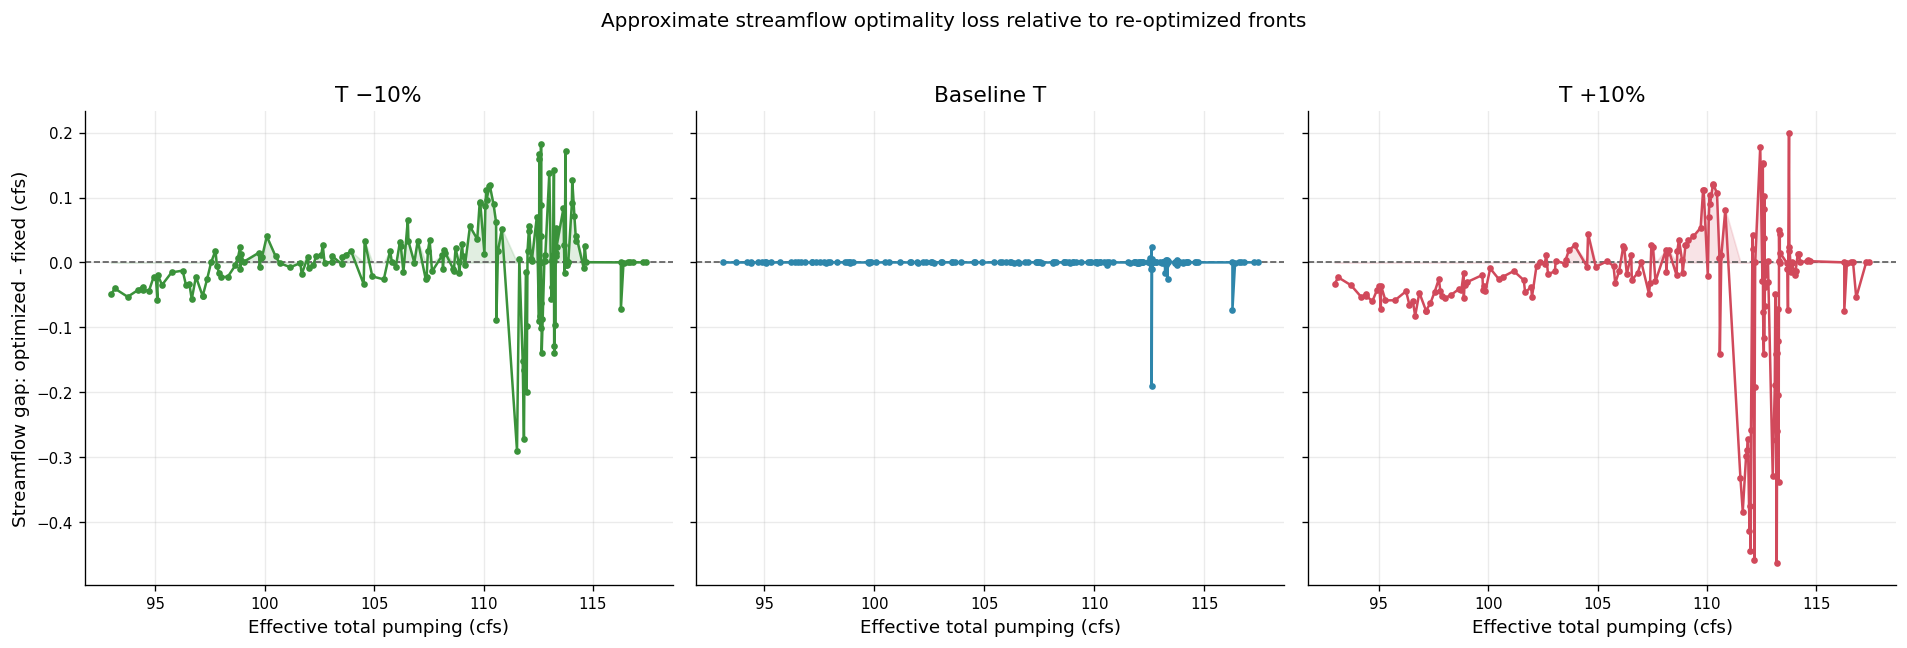

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_streamflow_optimality_gap_1x3.png


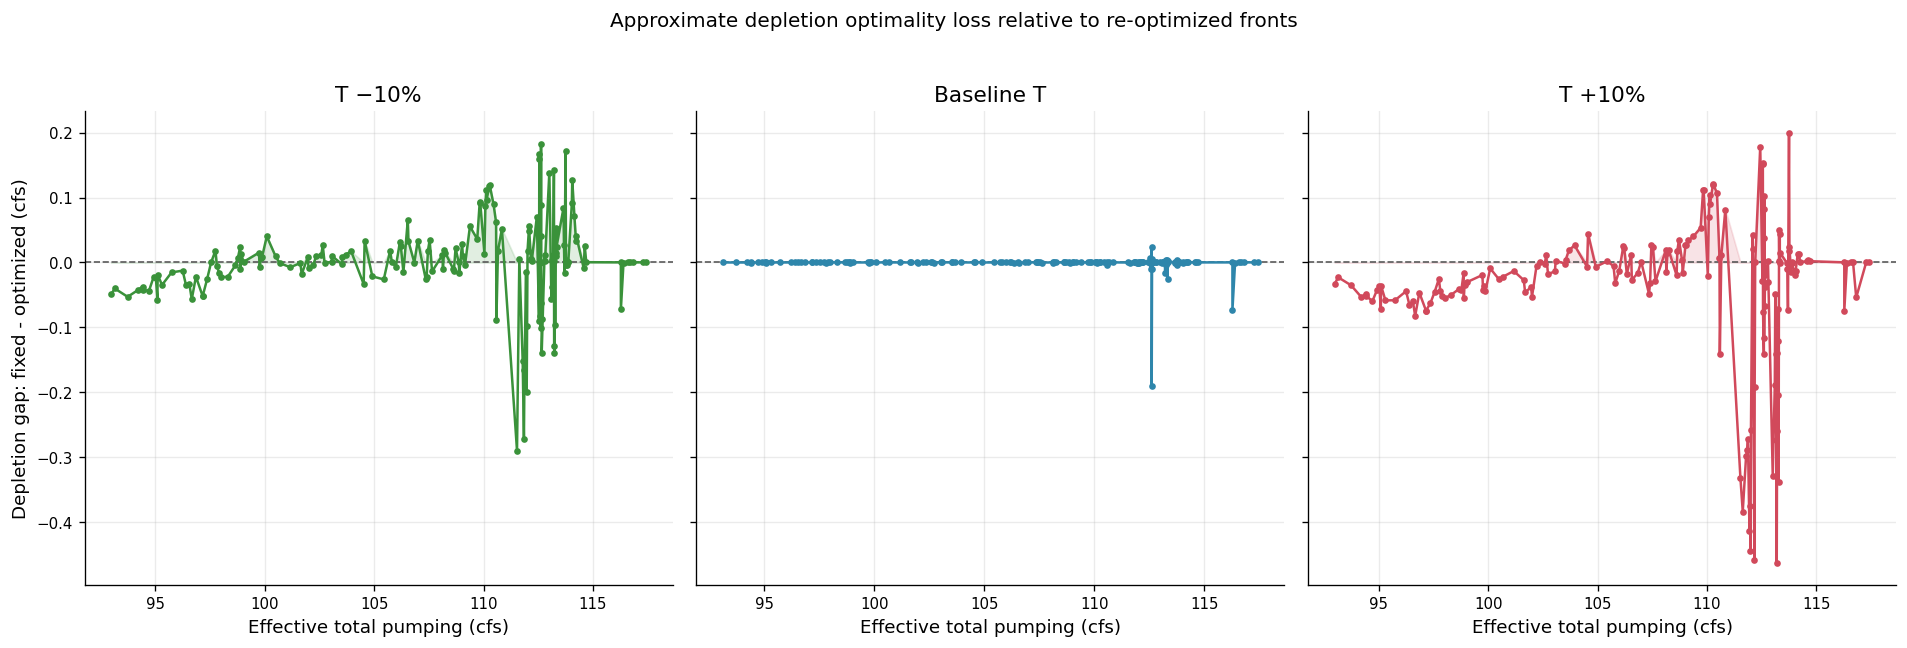

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_depletion_optimality_gap_1x3.png


In [5]:

# -----------------------------------------------------------------------------
# 5A. Streamflow gap plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)

for ax, spec in zip(axes, SCENARIO_SPECS):
    scenario = spec["scenario"]
    label = spec["label"]

    plot_df = gap_results.loc[
        (gap_results["scenario"] == scenario)
        & (gap_results["is_comparable_with_original_front"])
    ].copy()
    plot_df = plot_df.sort_values("fixed_pumping_cfs")

    ax.axhline(0, color="0.35", linestyle="--", linewidth=1.0)
    ax.plot(
        plot_df["fixed_pumping_cfs"],
        plot_df["streamflow_gap_cfs"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=SCENARIO_COLORS.get(scenario),
    )
    ax.fill_between(
        plot_df["fixed_pumping_cfs"],
        0,
        plot_df["streamflow_loss_cfs"],
        alpha=0.15,
        color=SCENARIO_COLORS.get(scenario),
    )

    ax.set_title(label)
    ax.set_xlabel("Effective total pumping (cfs)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Streamflow gap: optimized - fixed (cfs)")
fig.suptitle(
    "Approximate streamflow optimality loss relative to re-optimized fronts",
    y=1.03,
)

up.save_figure(fig, OUTPUT_DIR / "204_streamflow_optimality_gap_1x3.png")

# -----------------------------------------------------------------------------
# 5B. Depletion gap plot
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), sharey=True)

for ax, spec in zip(axes, SCENARIO_SPECS):
    scenario = spec["scenario"]
    label = spec["label"]

    plot_df = gap_results.loc[
        (gap_results["scenario"] == scenario)
        & (gap_results["is_comparable_with_original_front"])
    ].copy()
    plot_df = plot_df.sort_values("fixed_pumping_cfs")

    ax.axhline(0, color="0.35", linestyle="--", linewidth=1.0)
    ax.plot(
        plot_df["fixed_pumping_cfs"],
        plot_df["depletion_gap_cfs"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        color=SCENARIO_COLORS.get(scenario),
    )
    ax.fill_between(
        plot_df["fixed_pumping_cfs"],
        0,
        plot_df["depletion_loss_cfs"],
        alpha=0.15,
        color=SCENARIO_COLORS.get(scenario),
    )

    ax.set_title(label)
    ax.set_xlabel("Effective total pumping (cfs)")
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("Depletion gap: fixed - optimized (cfs)")
fig.suptitle(
    "Approximate depletion optimality loss relative to re-optimized fronts",
    y=1.03,
)

up.save_figure(fig, OUTPUT_DIR / "204_depletion_optimality_gap_1x3.png")


## 6. Plot scenario-level optimality-loss and fixed-better diagnostics

This figure summarizes the mean and maximum one-sided losses by T scenario.

This is useful for quickly seeing whether optimality loss is mainly associated with T being too low, T being too high, or both.


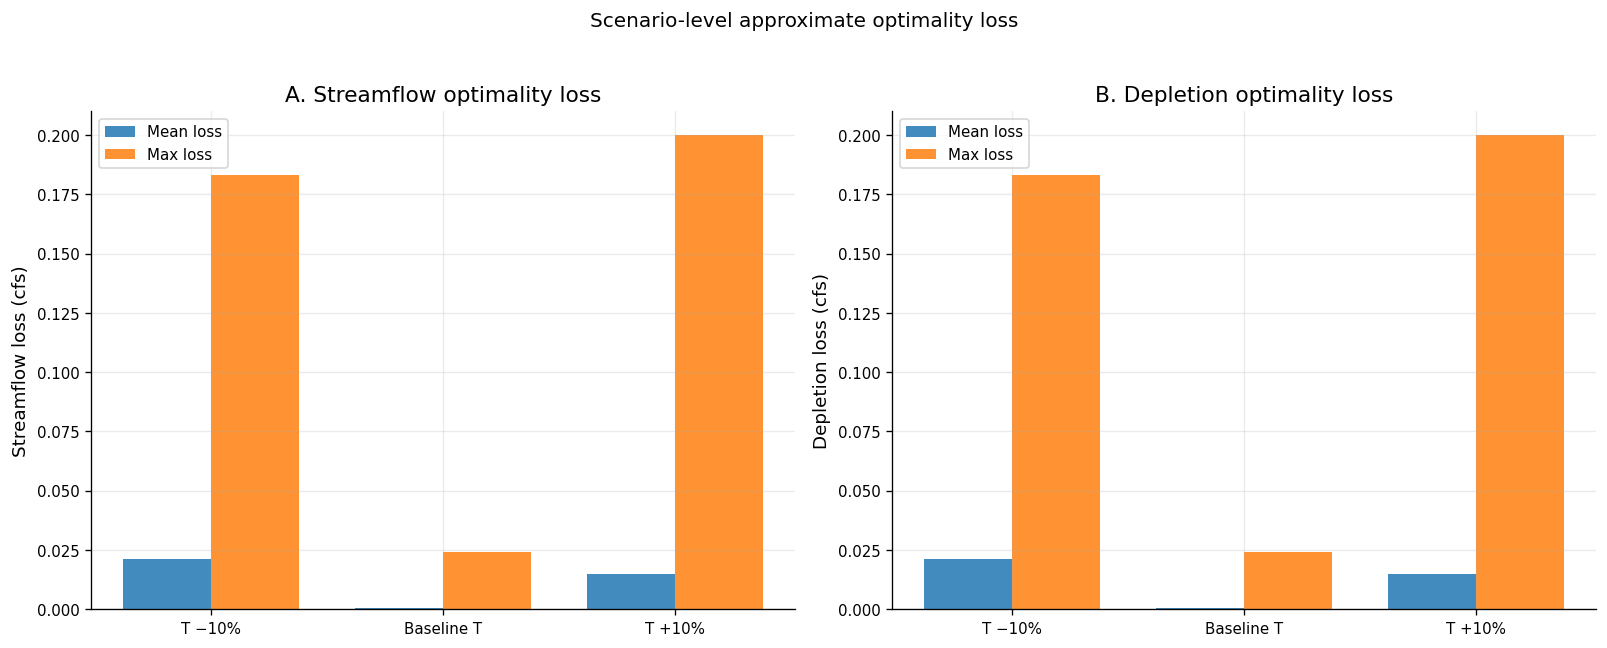

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_optimality_loss_summary_bars.png


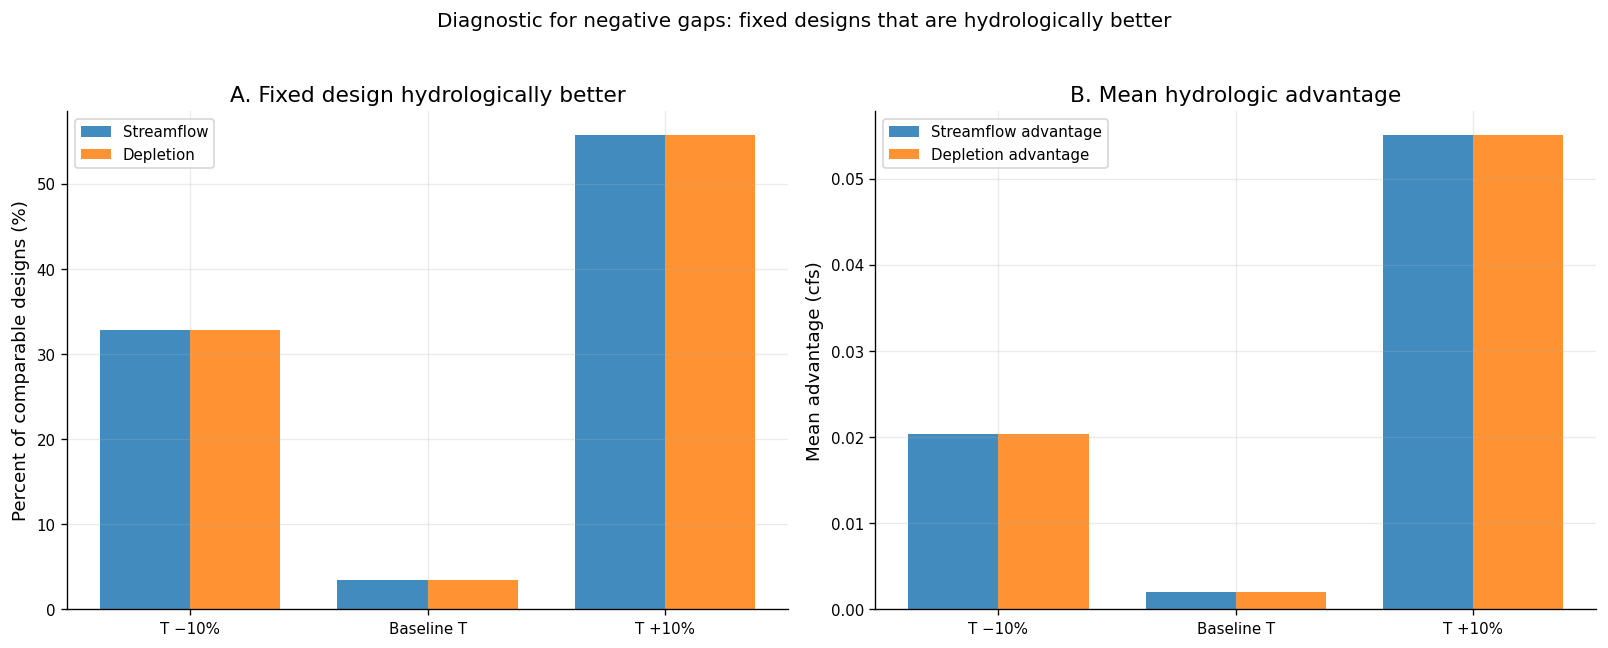

Saved: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_fixed_design_hydrologic_advantage_diagnostic.png


In [6]:

# -----------------------------------------------------------------------------
# Scenario-level summary bar plots.
# -----------------------------------------------------------------------------
plot_summary = gap_summary.copy()
x = np.arange(len(plot_summary))
bar_width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=True)

# Streamflow loss summary.
axes[0].bar(
    x - bar_width / 2,
    plot_summary["mean_streamflow_loss_cfs"],
    width=bar_width,
    label="Mean loss",
    alpha=0.85,
)
axes[0].bar(
    x + bar_width / 2,
    plot_summary["max_streamflow_loss_cfs"],
    width=bar_width,
    label="Max loss",
    alpha=0.85,
)
axes[0].set_title("A. Streamflow optimality loss")
axes[0].set_ylabel("Streamflow loss (cfs)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_summary["scenario_label"])
axes[0].legend()

# Depletion loss summary.
axes[1].bar(
    x - bar_width / 2,
    plot_summary["mean_depletion_loss_cfs"],
    width=bar_width,
    label="Mean loss",
    alpha=0.85,
)
axes[1].bar(
    x + bar_width / 2,
    plot_summary["max_depletion_loss_cfs"],
    width=bar_width,
    label="Max loss",
    alpha=0.85,
)
axes[1].set_title("B. Depletion optimality loss")
axes[1].set_ylabel("Depletion loss (cfs)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_summary["scenario_label"])
axes[1].legend()

fig.suptitle("Scenario-level approximate optimality loss", y=1.03)

up.save_figure(fig, OUTPUT_DIR / "204_optimality_loss_summary_bars.png")


# -----------------------------------------------------------------------------
# Fixed-design hydrologic advantage diagnostic.
# -----------------------------------------------------------------------------
# This diagnostic explains cases where the signed gap is negative. A negative
# streamflow gap means the fixed baseline design has higher streamflow than the
# interpolated original front at similar pumping. A negative depletion gap means
# the fixed baseline design has lower depletion. Because the original MOU
# objective is fish-dollars rather than pure streamflow-vs-pumping, these
# hydrologic advantages are possible and should not automatically be treated as
# errors.
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=True)

axes[0].bar(
    x - bar_width / 2,
    plot_summary["percent_fixed_better_streamflow"],
    width=bar_width,
    label="Streamflow",
    alpha=0.85,
)
axes[0].bar(
    x + bar_width / 2,
    plot_summary["percent_fixed_better_depletion"],
    width=bar_width,
    label="Depletion",
    alpha=0.85,
)
axes[0].set_title("A. Fixed design hydrologically better")
axes[0].set_ylabel("Percent of comparable designs (%)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_summary["scenario_label"])
axes[0].legend()

axes[1].bar(
    x - bar_width / 2,
    plot_summary["mean_fixed_streamflow_advantage_cfs"],
    width=bar_width,
    label="Streamflow advantage",
    alpha=0.85,
)
axes[1].bar(
    x + bar_width / 2,
    plot_summary["mean_fixed_depletion_advantage_cfs"],
    width=bar_width,
    label="Depletion advantage",
    alpha=0.85,
)
axes[1].set_title("B. Mean hydrologic advantage")
axes[1].set_ylabel("Mean advantage (cfs)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_summary["scenario_label"])
axes[1].legend()

fig.suptitle(
    "Diagnostic for negative gaps: fixed designs that are hydrologically better",
    y=1.03,
)

up.save_figure(fig, OUTPUT_DIR / "204_fixed_design_hydrologic_advantage_diagnostic.png")


## 7. Write a short Markdown results summary

This section writes a short interpretation file that can be copied into your report or used to guide discussion with your advisor.


In [7]:

# -----------------------------------------------------------------------------
# Write a concise Markdown interpretation of the 204 results.
# -----------------------------------------------------------------------------
def fmt_value(value: float) -> str:
    """Format a possibly-missing float for markdown text."""
    if pd.isna(value):
        return "not available"
    return f"{value:.6f}"


summary_lines = [
    "# 204 Results Summary — Optimality Loss Against Re-optimized Fronts",
    "",
    "## Purpose",
    "",
    "This notebook estimates an approximate optimality loss by comparing fixed baseline-design re-evaluations against original fully re-optimized MOU fronts.",
    "",
    "The comparison uses interpolation along each original optimized front so each fixed-design result can be compared to the optimized-front value at approximately the same pumping rate.",
    "",
    "## Interpretation of metrics",
    "",
    "- Streamflow gap = optimized-front streamflow - fixed-design streamflow.",
    "- Depletion gap = fixed-design depletion - optimized-front depletion.",
    "- Positive values indicate that the fixed baseline design performs worse than the re-optimized front at similar pumping.",
    "",
    "## Scenario summary",
    "",
    "| Scenario | Comparable designs (%) | Mean streamflow loss (cfs) | Max streamflow loss (cfs) | Fixed better by streamflow (%) | Mean depletion loss (cfs) | Max depletion loss (cfs) | Fixed better by depletion (%) |",
    "|---|---:|---:|---:|---:|---:|---:|---:|",
]

for _, row in gap_summary.iterrows():
    summary_lines.append(
        f"| {row['scenario_label']} | "
        f"{row['percent_comparable_after_interpolation']:.1f} | "
        f"{fmt_value(row['mean_streamflow_loss_cfs'])} | "
        f"{fmt_value(row['max_streamflow_loss_cfs'])} | "
        f"{row['percent_fixed_better_streamflow']:.1f} | "
        f"{fmt_value(row['mean_depletion_loss_cfs'])} | "
        f"{fmt_value(row['max_depletion_loss_cfs'])} | "
        f"{row['percent_fixed_better_depletion']:.1f} |"
    )

summary_lines.extend([
    "",
    "## Main takeaway",
    "",
    "This analysis links the fixed-design T-sensitivity results to the fully re-optimized MOU fronts. If the fixed-design gaps are close to zero, the baseline Pareto designs remain close to optimal even when T changes. If the gaps are larger, that suggests an additional cost of wrongness: the selected baseline designs may no longer represent the best available tradeoff under the corrected transmissivity assumption.",
    "",
    "The fixed-better diagnostic is included because the original MOU optimization used fish-dollars objectives rather than a direct hydrologic streamflow-vs-pumping objective. Therefore, some fixed baseline designs can plot hydrologically above the interpolated re-optimized fish-dollars front at similar pumping. These cases are not necessarily errors; they indicate that the fish-dollars front and a purely hydrologic front are not identical.",
    "",
    "Because this comparison relies on interpolation, it should be interpreted as an approximate optimality-loss diagnostic rather than an exact optimization metric.",
])

summary_text = "\n".join(summary_lines)
summary_path = OUTPUT_DIR / "204_optimality_loss_results_summary.md"
summary_path.write_text(summary_text)

print(summary_text)
print("Saved:", summary_path)


# 204 Results Summary — Optimality Loss Against Re-optimized Fronts

## Purpose

This notebook estimates an approximate optimality loss by comparing fixed baseline-design re-evaluations against original fully re-optimized MOU fronts.

The comparison uses interpolation along each original optimized front so each fixed-design result can be compared to the optimized-front value at approximately the same pumping rate.

## Interpretation of metrics

- Streamflow gap = optimized-front streamflow - fixed-design streamflow.
- Depletion gap = fixed-design depletion - optimized-front depletion.
- Positive values indicate that the fixed baseline design performs worse than the re-optimized front at similar pumping.

## Scenario summary

| Scenario | Comparable designs (%) | Mean streamflow loss (cfs) | Max streamflow loss (cfs) | Fixed better by streamflow (%) | Mean depletion loss (cfs) | Max depletion loss (cfs) | Fixed better by depletion (%) |
|---|---:|---:|---:|---:|---:|---:|---:|
| T −10% 

## 8. List final outputs

In [8]:

print("Saved files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(" -", f)


Saved files:
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_depletion_optimality_gap_1x3.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_fixed_design_hydrologic_advantage_diagnostic.png
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_optimality_loss_member_results.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_optimality_loss_results_summary.md
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized_fronts/204_optimality_loss_scenario_summary.csv
 - /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project/project_output/204_optimality_loss_against_reoptimized